The Python code in this notebook will load the simulation results stored in the `statistics` folder and will perform a Levene test.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

plt.style.use('seaborn-v0_8')

## Select input file to load

In [29]:
# input_file="statistics/results1Exp.txt"
# mean=200
# std=200

input_file="statistics/results1Log.txt"
mean=200
std=50

# input_file="statistics/results1Gamma.txt"
# mean=200
# std=50

# input_file="results1Triangular.txt"
# mean=200
# std=50

## Load and process data

In [30]:
df = pd.read_csv(input_file, header=None, names=["rng_mode", "n", "mean", "std", "delta2", "time"], sep="\t")

In [31]:
generators=df["rng_mode"].drop_duplicates().tolist()
generators.remove("ThreadLocalRandomSlow")  # This is the same a "ThreadLocalRandom". Only used for speed comparision. Removed from other tables.

## F-Test

In [32]:
# Generators to compare
generator1 = "ThreadLocalRandom"
generator2 = "Drand48"

# Number of generated PRN per sample value
n = 10**8

=== Estimates of population variances ===
ThreadLocalRandom: σ² ≈ 2445.875 (from mean-variance)
Drand48: σ² ≈ 44163.897 (from mean-variance)

=== F-test (based on aggregated data) ===
F statistics: 18.056
p value (double sided): 0.00000000
The variances are significantly different (p < 0.05).


Text(0, 0.5, 'Standard deviation')

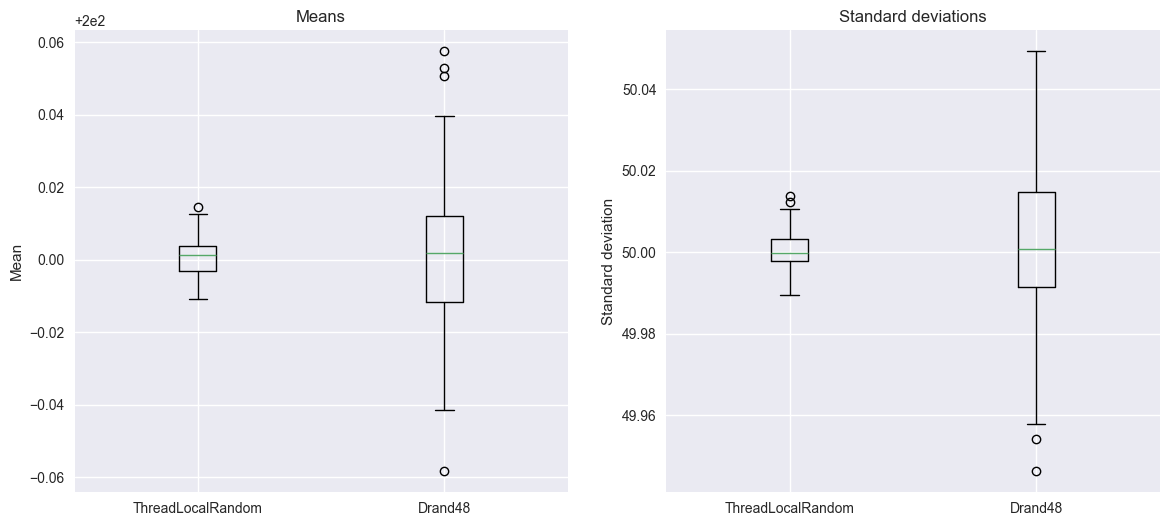

In [33]:
mean1 = df[df["rng_mode"] == generator1]["mean"]
mean2 = df[df["rng_mode"] == generator2]["mean"]
std1 = df[df["rng_mode"] == generator1]["std"]
std2 = df[df["rng_mode"] == generator2]["std"]

# 1. Estimating the population variance from sample means
var_mean1 = np.var(mean1, ddof=1)  # Variance of the means (unbiased)
var_mean2 = np.var(mean2, ddof=1)

# Estimation of the population variance
sigma1_sq = var_mean1 * n
sigma2_sq = var_mean2 * n

print("=== Estimates of population variances ===")
print(f"{generator1}: σ² ≈ {sigma1_sq:.3f} (from mean-variance)")
print(f"{generator2}: σ² ≈ {sigma2_sq:.3f} (from mean-variance)")

# 2. F-test for differences in variance (assuming a normal distribution)
# F = greater variance / smaller variance
f_stat = max(sigma2_sq, sigma1_sq) / min(sigma2_sq, sigma1_sq)
df1 = len(mean1) - 1
df2 = len(mean2) - 2

# Double-sided p-value
p_value = 2 * (1 - stats.f.cdf(f_stat, df1, df2))

print(f"\n=== F-test (based on aggregated data) ===")
print(f"F statistics: {f_stat:.3f}")
print(f"p value (double sided): {p_value:.8f}")

# 3. Interpretation
alpha = 0.05
if p_value < alpha:
    print("The variances are significantly different (p < 0.05).")
else:
    print("No significant difference in the variances (p >= 0.05).")

# 4. Box plots of the means and standard deviations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.boxplot([mean1, mean2], tick_labels=[generator1, generator2])
ax1.set_title('Means')
ax1.set_ylabel('Mean')

ax2.boxplot([std1, std2], tick_labels=[generator1, generator2])
ax2.set_title('Standard deviations')
ax2.set_ylabel('Standard deviation')